Loading Libraries ---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading Dataset ---

In [2]:
df = pd.read_csv("C:/Data Analytics/Projects/Project3 E-commerce Customer Behavior & Revenue Analytics/online_retail_clean.csv")

Converting Date Column ---

In [4]:
df["InvoiceDate_Clean"] = pd.to_datetime(df["InvoiceDate_Clean"], format="%d-%m-%Y %H:%M")

Creating Invoice Month ---

In [5]:
df["InvoiceMonth"] = (
    df["InvoiceDate_Clean"]
    .dt.to_period("M")
)

Creating Cohort Month ---

In [6]:
cohort = (
    df.groupby("CustomerID")
      ["InvoiceMonth"]
      .min()
)

In [7]:
df["CohortMonth"] = (
    df["CustomerID"]
      .map(cohort)
)

Creating Cohort Index ---

In [8]:
invoice_year = df["InvoiceMonth"].dt.year
invoice_month = df["InvoiceMonth"].dt.month

cohort_year = df["CohortMonth"].dt.year
cohort_month = df["CohortMonth"].dt.month

In [9]:
df["CohortIndex"] = (
    (invoice_year - cohort_year) * 12
    +
    (invoice_month - cohort_month)
    + 1
)

Cohort Table ---

In [10]:
cohort_data = (
    df.groupby(
        ["CohortMonth","CohortIndex"]
    )["CustomerID"]
    .nunique()
    .reset_index()
)

Pivot ---

In [11]:
cohort_counts = (
    cohort_data.pivot(
        index="CohortMonth",
        columns="CohortIndex",
        values="CustomerID"
    )
)

Retention Matrix ---

In [12]:
cohort_sizes = cohort_counts.iloc[:,0]

In [13]:
retention = (
    cohort_counts
    .divide(
        cohort_sizes,
        axis=0
    )
)

In [14]:
retention = retention.round(3) * 100

Retention Heatmap ---

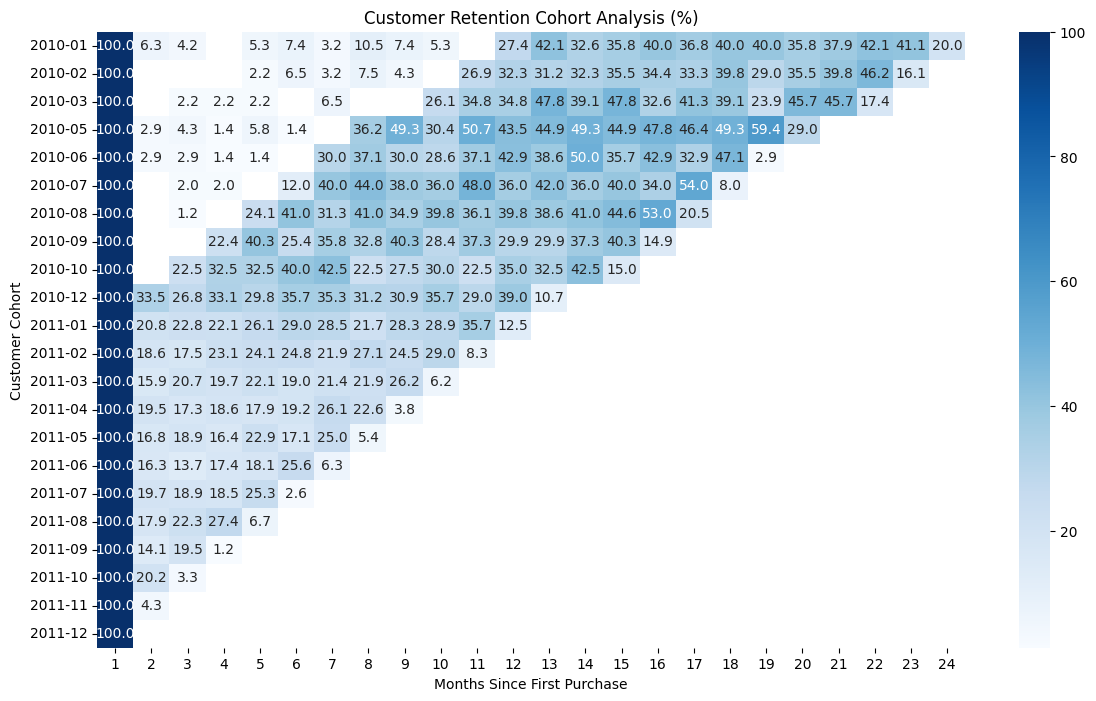

In [15]:
plt.figure(figsize=(14,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Customer Retention Cohort Analysis (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort")
plt.show()

Saving the Cohort Table ---

In [16]:
retention.to_csv("C:/Data Analytics/Projects/Project3 E-commerce Customer Behavior & Revenue Analytics/cohort_retention.csv")

In [17]:
retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2010-01,100.0,6.3,4.2,NaN,5.3,7.4,3.2,10.5,7.4,5.3,...,35.8,40.0,36.8,40.0,40.0,35.8,37.9,42.1,41.1,20.0
2010-02,100.0,NaN,NaN,NaN,2.2,6.5,3.2,7.5,4.3,NaN,...,35.5,34.4,33.3,39.8,29.0,35.5,39.8,46.2,16.1,NaN
2010-03,100.0,NaN,2.2,2.2,2.2,NaN,6.5,NaN,NaN,26.1,...,47.8,32.6,41.3,39.1,23.9,45.7,45.7,17.4,NaN,NaN
2010-05,100.0,2.9,4.3,1.4,5.8,1.4,NaN,36.2,49.3,30.4,...,44.9,47.8,46.4,49.3,59.4,29.0,NaN,NaN,NaN,NaN
2010-06,100.0,2.9,2.9,1.4,1.4,NaN,30.0,37.1,30.0,28.6,...,35.7,42.9,32.9,47.1,2.9,NaN,NaN,NaN,NaN,NaN


In [19]:
df["InvoiceDate_Clean"].min()

Timestamp('2010-01-12 08:26:00')

In [20]:
df["InvoiceDate_Clean"].max()

Timestamp('2011-12-10 17:19:00')

In [21]:
df[["InvoiceDate","InvoiceDate_Clean"]].sample(10)

,InvoiceDate,InvoiceDate_Clean
303325,07-07-2011 15:45,2011-07-07 15:45:00
204716,10-10-2011 17:09,2011-10-10 17:09:00
313565,11/17/2011 14:02,2011-11-17 14:02:00
273005,11-09-2011 13:52,2011-09-11 13:52:00
332634,11/22/2011 12:09,2011-11-22 12:09:00
55869,4/19/2011 10:04,2011-04-19 10:04:00
360458,11-04-2011 12:45,2011-04-11 12:45:00
26748,12-05-2010 16:00,2010-05-12 16:00:00
191362,9/15/2011 15:21,2011-09-15 15:21:00
189878,10-07-2011 15:26,2011-07-10 15:26:00
